<a href="https://colab.research.google.com/github/essence-git/esssencegit-workflow/blob/main/stage4_surrogate_prefidelity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 4 — Pre-Adaptation Surrogate Decision Tree + Pre-Adaptation Fidelity

**What happens in this stage:**
1. Base model is permanently frozen — no further weight changes ever
2. Surrogate Decision Tree trained to mimic the frozen detector
3. Pre-adaptation PAF (Post-hoc Agreement Fidelity) computed
4. Human-readable if-then rules exported for analyst use
5. Everything saved as the pre-adaptation baseline for Stage 7 comparison

**Why freeze before building the surrogate:**
The surrogate must faithfully represent the detector *as it stands before any drift*.
If the model changes after this point, the surrogate becomes invalid.
Freezing here guarantees the pre-adaptation surrogate and fidelity score
are a clean baseline that Stage 7 can compare against.

## 4.0 — Setup: imports and load assets

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import copy, gc, random, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset

SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device : {DEVICE}')

SAVE_DIR = '/content/drive/MyDrive/gru_iot_project/'

# ── Load Stage 1 assets ───────────────────────────────────────────────────────
X_test       = np.load(SAVE_DIR + 'X_test.npy')
y_test       = np.load(SAVE_DIR + 'y_test.npy')

with open(SAVE_DIR + 'stage1_assets.pkl', 'rb') as f:
    s1 = pickle.load(f)
baseline_means_raw = s1['baseline_means_raw']
scaler             = s1['scaler']
FEATURES           = s1['FEATURES']
WINDOW             = s1['WINDOW']
test_source        = s1['test_source']

# ── Load Stage 2 assets ───────────────────────────────────────────────────────
with open(SAVE_DIR + 'stage2_assets.pkl', 'rb') as f:
    s2 = pickle.load(f)
THRESHOLD_T = s2['THRESHOLD_T']

# ── Load Stage 3 assets ───────────────────────────────────────────────────────
test_errors = np.load(SAVE_DIR + 'test_errors.npy')
y_pred      = np.load(SAVE_DIR + 'y_pred_baseline.npy')

with open(SAVE_DIR + 'stage3_assets.pkl', 'rb') as f:
    s3 = pickle.load(f)
baseline1_metrics = s3['baseline1_metrics']

print(f'THRESHOLD_T  : {THRESHOLD_T:.6f}')
print(f'X_test       : {X_test.shape}')
print(f'Features     : {len(FEATURES)}')

Mounted at /content/drive
Device : cpu
THRESHOLD_T  : 0.064853
X_test       : (113360, 10, 19)
Features     : 19


## 4.1 — Rebuild model and FREEZE all base weights

This is the permanent freeze point. After this cell, the GRU encoder, decoder,
bottleneck and decoder_expand weights are locked forever.
Only LoRA matrices added in Stage 6 will be trainable.

In [2]:
class GRUAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.encoder = nn.GRU(input_size, hidden_size, num_layers=num_layers,
                              batch_first=True, dropout=dropout, bidirectional=True)
        self.enc_dropout    = nn.Dropout(dropout)
        self.bottleneck     = nn.Linear(hidden_size * 2, 32)
        self.decoder_expand = nn.Linear(32, hidden_size)
        self.dec_dropout    = nn.Dropout(dropout)
        self.decoder = nn.GRU(hidden_size, input_size, num_layers=num_layers,
                              batch_first=True, dropout=dropout)

    def forward(self, x):
        seq_len      = x.size(1)
        enc_out, _   = self.encoder(x)
        enc_out      = self.enc_dropout(enc_out[:, -1, :])
        bottleneck   = torch.relu(self.bottleneck(enc_out))
        dec_input    = self.dec_dropout(self.decoder_expand(bottleneck))
        dec_input    = dec_input.unsqueeze(1).repeat(1, seq_len, 1)
        output, _    = self.decoder(dec_input)
        return output, bottleneck

model = GRUAutoencoder(input_size=len(FEATURES)).to(DEVICE)
model.load_state_dict(torch.load(SAVE_DIR + 'gru_best_model.pt', map_location=DEVICE))

# ── PERMANENT FREEZE — no base weight ever changes after this point ───────────
for param in model.parameters():
    param.requires_grad = False

model.eval()

# Verify freeze
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print('Base model FROZEN.')
print(f'  Frozen parameters    : {frozen:,}')
print(f'  Trainable parameters : {trainable:,}  (should be 0)')
print()
print('LoRA matrices added in Stage 6 will be the ONLY trainable parameters.')

Base model FROZEN.
  Frozen parameters    : 120,501
  Trainable parameters : 0  (should be 0)

LoRA matrices added in Stage 6 will be the ONLY trainable parameters.


## 4.2 — Prepare surrogate training data

The surrogate Decision Tree trains on the **19 raw unscaled features** of each test sequence
using the **GRU detector labels** (not ground truth) as targets.

This is the key design choice: the surrogate learns to mimic the detector, not to classify
attacks. Its job is to produce human-readable rules that explain *what the detector is seeing*,
not to be a classifier in its own right.

Raw unscaled features are used (not the [0,1] scaled values) so that the rule thresholds
appear in original units — packet counts, byte counts, flag counts — that an analyst
can interpret directly.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 4 — CELL 4.2 (replacement)
# ══════════════════════════════════════════════════════════════════════════════

# Use MEAN of all 10 flows in each window (not just last flow).
# This better approximates what the GRU sees across the full sequence.
X_test_scaled_mean = X_test.mean(axis=1)                          # (n_seq, 19)
X_test_mean_raw    = scaler.inverse_transform(X_test_scaled_mean) # original units

# Keep last-flow raw for the explanation function (explain_alert uses this)
X_test_last_scaled = X_test[:, -1, :]
X_test_last_raw    = scaler.inverse_transform(X_test_last_scaled)

# Remove PROTOCOL — categorical feature, meaningless as a continuous split
SURROGATE_FEATURES = [f for f in FEATURES if f != 'PROTOCOL']
feature_mask       = [i for i, f in enumerate(FEATURES) if f != 'PROTOCOL']
X_surr_all         = X_test_mean_raw[:, feature_mask]  # (n_seq, 18)
y_surr_all         = y_pred.astype(int)

# Balanced sampling — equal normal and anomaly counts, no class_weight needed
normal_idx  = np.where(y_surr_all == 0)[0]
anomaly_idx = np.where(y_surr_all == 1)[0]
n_min       = min(len(normal_idx), len(anomaly_idx))

np.random.seed(SEED)
sampled_normal  = np.random.choice(normal_idx,  n_min, replace=False)
sampled_anomaly = np.random.choice(anomaly_idx, n_min, replace=False)
balanced_idx    = np.concatenate([sampled_normal, sampled_anomaly])
np.random.shuffle(balanced_idx)

X_balanced = X_surr_all[balanced_idx]
y_balanced = y_surr_all[balanced_idx]

# 80 / 20 split within balanced set
split_idx    = int(0.80 * len(X_balanced))
X_surr_train = X_balanced[:split_idx]
y_surr_train = y_balanced[:split_idx]
X_surr_eval  = X_balanced[split_idx:]
y_surr_eval  = y_balanced[split_idx:]

print('Surrogate training data (balanced):')
print(f'  Total sequences : {len(X_surr_train):,}')
print(f'  Normal labels   : {(y_surr_train == 0).sum():,}  ({(y_surr_train == 0).mean():.1%})')
print(f'  Anomaly labels  : {(y_surr_train == 1).sum():,}  ({(y_surr_train == 1).mean():.1%})')
print(f'  Features used   : {len(SURROGATE_FEATURES)}  (PROTOCOL excluded)')
print(f'\nSurrogate eval data : {len(X_surr_eval):,} sequences')

Surrogate training data (balanced):
  Total sequences : 62,820
  Normal labels   : 31,389  (50.0%)
  Anomaly labels  : 31,431  (50.0%)
  Features used   : 18  (PROTOCOL excluded)

Surrogate eval data : 15,706 sequences


## 4.3 — Train surrogate Decision Tree

`max_depth=5` produces rules that are deep enough to capture meaningful patterns
but shallow enough to remain human-readable.
`class_weight='balanced'` compensates for the normal/anomaly imbalance in detector labels.

Surrogate Decision Tree trained.
  Max depth          : 7
  Leaves             : 126
  Overall agreement  : 0.9184  (91.84%)
  Anomaly agreement  : 0.9070  (90.7%)
  Normal agreement   : 0.9296  (93.0%)
  Root split feature : RST_FLAG_CNT

Decision Tree Rules:
|--- RST_FLAG_CNT <= 0.15
|   |--- TCP_WIN_MAX_IN <= 8726.15
|   |   |--- PKT_LEN_MEAN <= 139.63
|   |   |   |--- SRC_TO_DST_IAT_MIN <= 6004923.50
|   |   |   |   |--- ACTIVE_MEAN <= 2023237.19
|   |   |   |   |   |--- IN_BYTES <= 1393.41
|   |   |   |   |   |   |--- FIN_FLAG_CNT <= 0.35
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- FIN_FLAG_CNT >  0.35
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- IN_BYTES >  1393.41
|   |   |   |   |   |   |--- FIN_FLAG_CNT <= 0.45
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- FIN_FLAG_CNT >  0.45
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- ACTIVE_MEAN >  2023237.19
|   |   |   |   |   |--- SYN_FLAG_CNT <=

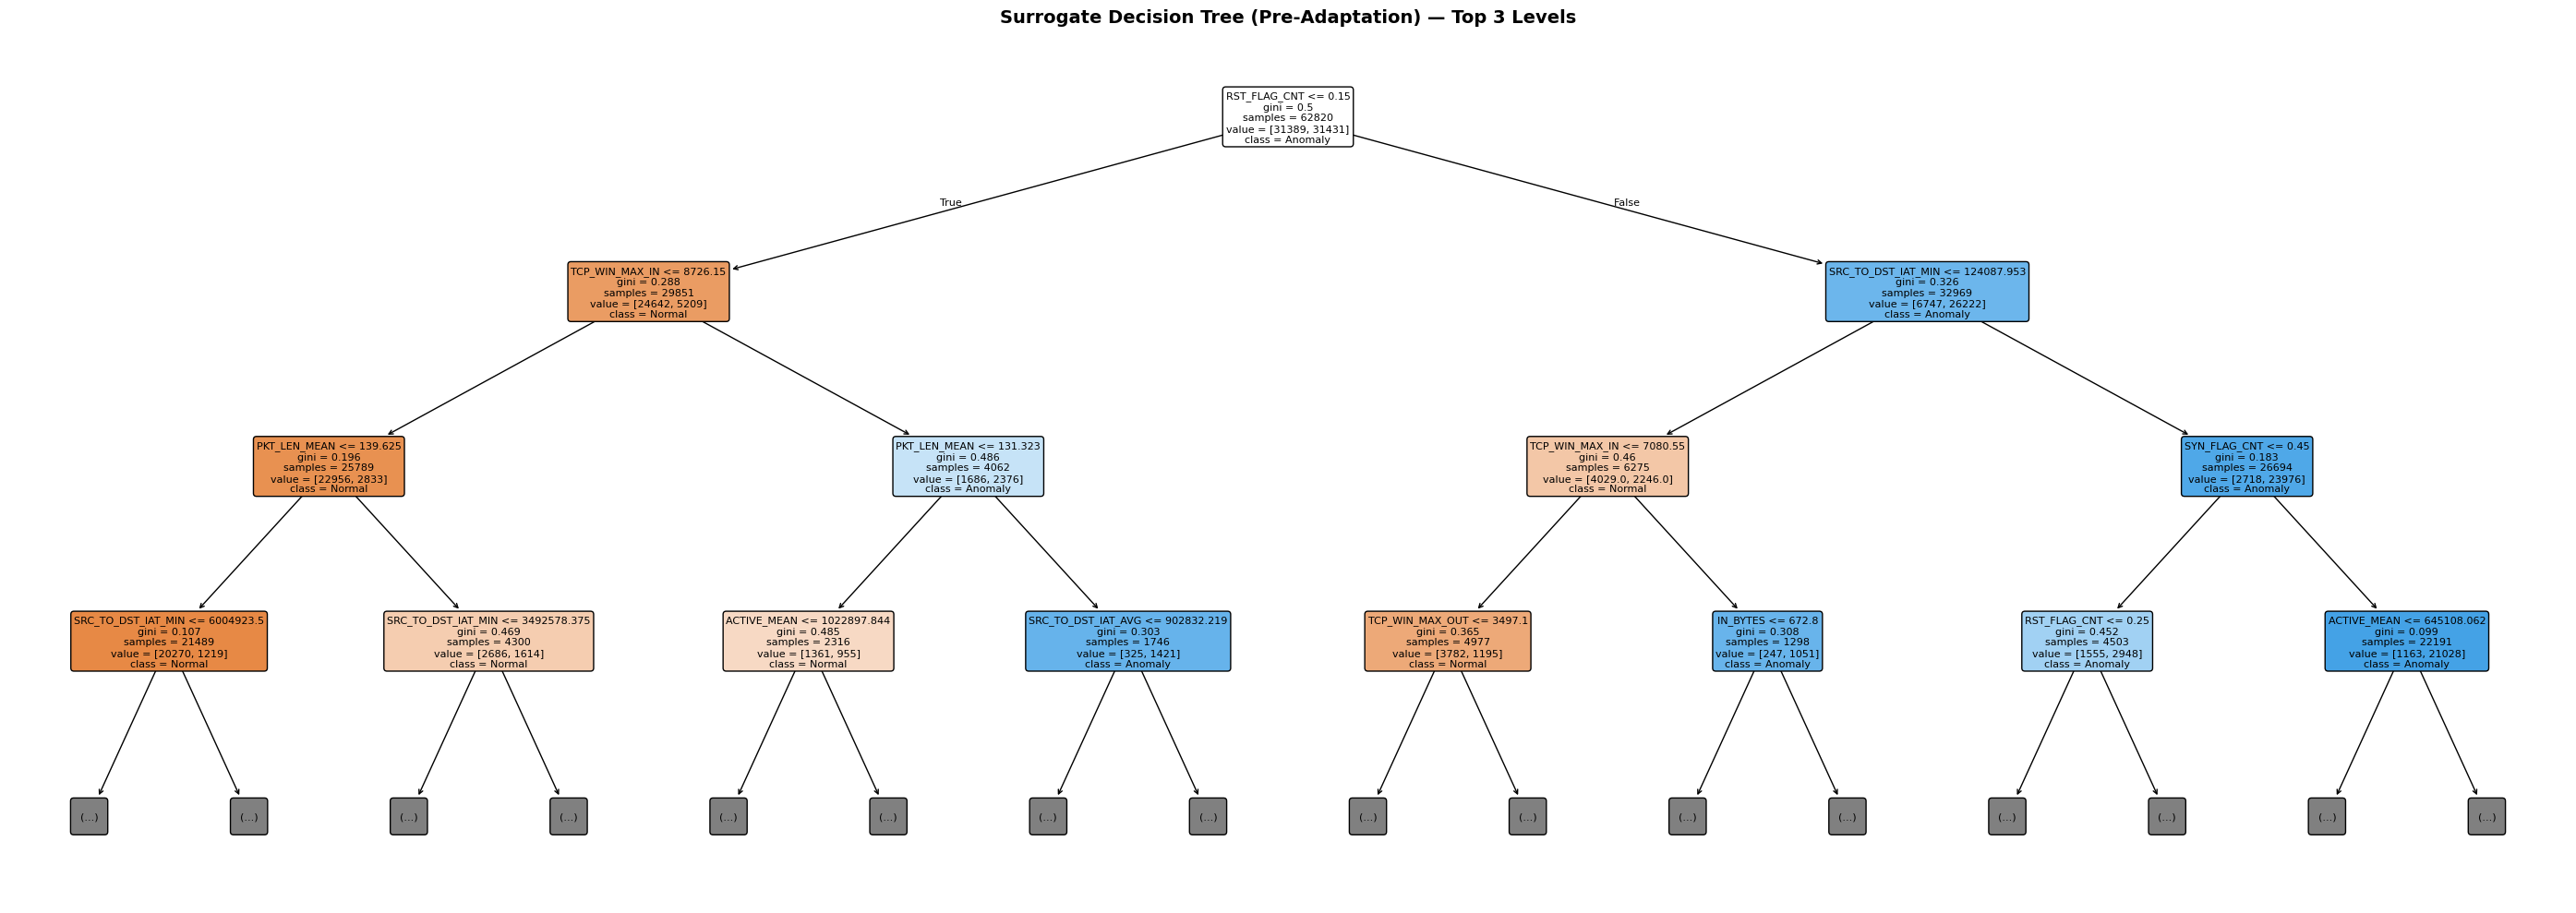

Decision tree diagram saved.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 4 — CELL 4.3 (replacement)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.tree import plot_tree

surrogate_pre = DecisionTreeClassifier(
    max_depth    = 7,
    class_weight = None,   # balanced sampling already done in cell 4.2
    random_state = SEED
)
surrogate_pre.fit(X_surr_train, y_surr_train)

# ── Agreement breakdown ───────────────────────────────────────────────────────
surr_pred_eval = surrogate_pre.predict(X_surr_eval)
overall_agree  = accuracy_score(y_surr_eval, surr_pred_eval)

anom_mask  = y_surr_eval == 1
norm_mask  = y_surr_eval == 0
anom_agree = accuracy_score(y_surr_eval[anom_mask], surr_pred_eval[anom_mask])
norm_agree = accuracy_score(y_surr_eval[norm_mask], surr_pred_eval[norm_mask])

print('Surrogate Decision Tree trained.')
print(f'  Max depth          : {surrogate_pre.get_depth()}')
print(f'  Leaves             : {surrogate_pre.get_n_leaves()}')
print(f'  Overall agreement  : {overall_agree:.4f}  ({overall_agree * 100:.2f}%)')
print(f'  Anomaly agreement  : {anom_agree:.4f}  ({anom_agree * 100:.1f}%)')
print(f'  Normal agreement   : {norm_agree:.4f}  ({norm_agree * 100:.1f}%)')
print(f'  Root split feature : {SURROGATE_FEATURES[surrogate_pre.tree_.feature[0]]}')

# ── Text rules ────────────────────────────────────────────────────────────────
print('\nDecision Tree Rules:')
print('=' * 70)
rules_text = export_text(surrogate_pre, feature_names=SURROGATE_FEATURES)
print(rules_text[:3000])
if len(rules_text) > 3000:
    print(f'... (truncated — full tree has {surrogate_pre.get_n_leaves()} leaves)')

# ── Visual tree diagram ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    surrogate_pre,
    feature_names = SURROGATE_FEATURES,
    class_names   = ['Normal', 'Anomaly'],
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    ax            = ax,
    max_depth     = 3        # top 3 levels for readability
)
ax.set_title(
    'Surrogate Decision Tree (Pre-Adaptation) — Top 3 Levels',
    fontweight='bold', fontsize=14
)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'surrogate_tree_pre.png', dpi=150, bbox_inches='tight')
plt.show()
print('Decision tree diagram saved.')


## 4.4 — Pre-adaptation PAF (Post-hoc Agreement Fidelity)

PAF measures how faithfully the surrogate mirrors the detector.
It is computed separately for anomalous and normal predictions,
then combined as a weighted score:

```
PAF = 0.7 × PAF_anomalous + 0.3 × PAF_normal
```

Anomalous agreement is weighted higher (0.7) because explanation faithfulness
matters most precisely when the detector fires an alert — that is when an analyst
relies on the surrogate rules to decide whether to act.

In [6]:
def compute_paf(surrogate, X, gru_labels, verbose=True):
    """
    Compute weighted Post-hoc Agreement Fidelity.

    Parameters
    ----------
    surrogate  : fitted DecisionTreeClassifier
    X          : raw unscaled features (n_sequences, 19)
    gru_labels : GRU detector predictions (0/1)
    verbose    : print breakdown

    Returns
    -------
    paf_weighted, paf_anomalous, paf_normal
    """
    surr_preds = surrogate.predict(X)

    # PAF on anomalous subset (where GRU fired)
    anom_mask    = gru_labels == 1
    paf_anom     = accuracy_score(gru_labels[anom_mask], surr_preds[anom_mask]) \
                   if anom_mask.sum() > 0 else 0.0

    # PAF on normal subset (where GRU did not fire)
    norm_mask    = gru_labels == 0
    paf_norm     = accuracy_score(gru_labels[norm_mask], surr_preds[norm_mask]) \
                   if norm_mask.sum() > 0 else 0.0

    # Weighted PAF
    paf_weighted = 0.7 * paf_anom + 0.3 * paf_norm

    if verbose:
        print(f'  PAF anomalous  : {paf_anom:.4f}  (weight 0.7)')
        print(f'  PAF normal     : {paf_norm:.4f}  (weight 0.3)')
        print(f'  PAF weighted   : {paf_weighted:.4f}  <- fidelity score')
        print(f'  Anomalous seqs : {anom_mask.sum():,}')
        print(f'  Normal seqs    : {norm_mask.sum():,}')

    return paf_weighted, paf_anom, paf_norm


print('Pre-adaptation PAF (on surrogate eval set):')
print('-' * 45)
paf_pre, paf_pre_anom, paf_pre_norm = compute_paf(
    surrogate_pre, X_surr_eval, y_surr_eval
)
print()
print(f'PRE-ADAPTATION PAF = {paf_pre:.4f}')
print()
print('This is the fidelity baseline.')
print('Stage 7 fidelity gate checks post-adaptation PAF against T_PAF = 0.80.')
print('If post-adaptation PAF < T_PAF, the new surrogate is rejected and this one is restored.')

Pre-adaptation PAF (on surrogate eval set):
---------------------------------------------
  PAF anomalous  : 0.9070  (weight 0.7)
  PAF normal     : 0.9296  (weight 0.3)
  PAF weighted   : 0.9138  <- fidelity score
  Anomalous seqs : 7,832
  Normal seqs    : 7,874

PRE-ADAPTATION PAF = 0.9138

This is the fidelity baseline.
Stage 7 fidelity gate checks post-adaptation PAF against T_PAF = 0.80.
If post-adaptation PAF < T_PAF, the new surrogate is rejected and this one is restored.


## 4.5 — Feature importance from surrogate

The surrogate's feature importances reveal which of the 19 features drive
the detector's decisions. These are the features that will appear most
frequently in the human-readable alert explanations in Stage 7.
They are also the top-K features used to compute ESS (Explanation Stability Score)
after LoRA adaptation.

Surrogate feature importances (pre-adaptation):
                Feature  Importance
           RST_FLAG_CNT    0.523666
     SRC_TO_DST_IAT_MIN    0.152978
         TCP_WIN_MAX_IN    0.100395
           PKT_LEN_MEAN    0.072054
           SYN_FLAG_CNT    0.038324
            ACTIVE_MEAN    0.029996
        TCP_WIN_MAX_OUT    0.027265
               IN_BYTES    0.022549
           FIN_FLAG_CNT    0.011534
          FLOW_IAT_MEAN    0.010752
     SRC_TO_DST_IAT_AVG    0.004769
  FLOW_DURATION_SECONDS    0.003660
         MIN_IP_PKT_LEN    0.001721
          DOWN_UP_RATIO    0.000185
       LONGEST_FLOW_PKT    0.000151
SRC_TO_DST_SECOND_BYTES    0.000000
              OUT_BYTES    0.000000
      SHORTEST_FLOW_PKT    0.000000

Top-5 features (ESS baseline): ['RST_FLAG_CNT', 'SRC_TO_DST_IAT_MIN', 'TCP_WIN_MAX_IN', 'PKT_LEN_MEAN', 'SYN_FLAG_CNT']


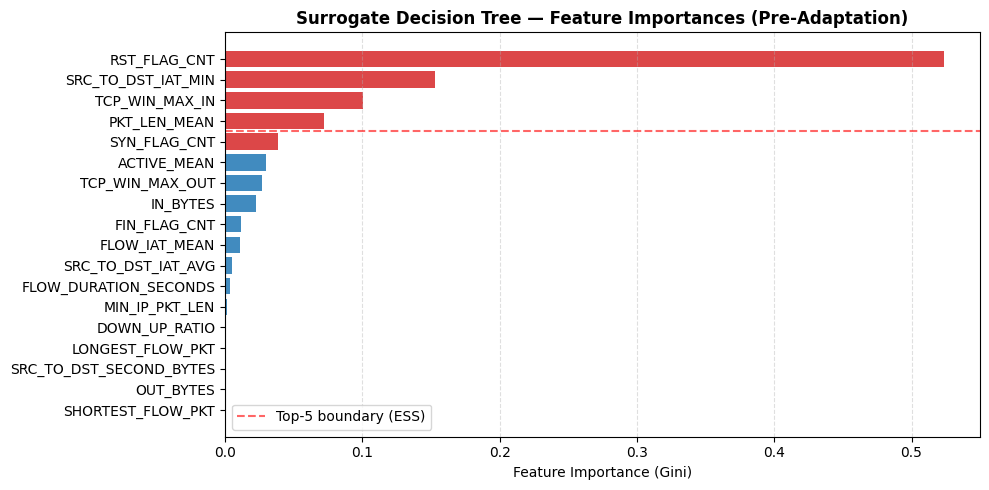

Feature importance plot saved.


In [7]:
importances = surrogate_pre.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'    : SURROGATE_FEATURES,   # ← correct, 18 features
    'Importance' : importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Top 5 features — used for ESS computation in Stage 7
top5_features_pre = feat_imp_df['Feature'].head(5).tolist()

print('Surrogate feature importances (pre-adaptation):')
print(feat_imp_df.to_string(index=False))
print(f'\nTop-5 features (ESS baseline): {top5_features_pre}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#d62728' if i < 5 else '#1f77b4' for i in range(len(feat_imp_df))]
ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
        color=colors[::-1], alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Surrogate Decision Tree — Feature Importances (Pre-Adaptation)',
             fontweight='bold')
ax.axhline(y=len(FEATURES) - 5 - 0.5, color='red', linestyle='--',
           alpha=0.6, label='Top-5 boundary (ESS)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4, axis='x')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'surrogate_feature_importance_pre.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved.')

## 4.6 — Human-readable alert explanation function

This is the analyst-facing output. For any flagged sequence it produces:
- Per-feature ratio vs normal baseline (in original units)
- Direction (above/below normal)
- Attack pattern label based on the combination of top deviating features
- Traffic source context (Src IP, Src Port, Dst IP, Dst Port)

The attack pattern matcher uses the 19 features available in this dataset.
Rules are based on known IoT attack signatures.

In [11]:
# ── Attack pattern matcher ────────────────────────────────────────────────────
# Maps combinations of top deviating features to named attack patterns.
# Each rule checks which features are significantly above/below baseline.

def match_attack_pattern(deviations):
    """
    deviations: dict of {feature_name: ratio} for top deviating features
    ratio > 1 means above normal, ratio < 1 means below normal
    Returns a string describing the likely attack pattern.
    """
    feats = set(deviations.keys())
    ratios = deviations

    # SYN flood / port scan
    if 'SYN_FLAG_CNT' in feats and ratios.get('SYN_FLAG_CNT', 1) > 5:
        if ratios.get('FLOW_DURATION_SECONDS', 1) < 0.5:
            return 'SYN flood or port scan (Recon/DDoS)'
        return 'SYN flood (DDoS)'

    # RST injection
    if 'RST_FLAG_CNT' in feats and ratios.get('RST_FLAG_CNT', 1) > 5:
        return 'RST injection or TCP session disruption'

    # FIN scan
    if 'FIN_FLAG_CNT' in feats and ratios.get('FIN_FLAG_CNT', 1) > 5:
        if ratios.get('FLOW_DURATION_SECONDS', 1) < 0.5:
            return 'FIN scan (Recon)'
        return 'FIN flood'

    # Volumetric flood (DDoS/DoS)
    if 'SRC_TO_DST_SECOND_BYTES' in feats and ratios.get('SRC_TO_DST_SECOND_BYTES', 1) > 5:
        if ratios.get('IN_BYTES', 1) > 3:
            return 'Volumetric flood — likely DDoS or DoS'

    # Mirai-style C2 / bot traffic
    if 'IN_BYTES' in feats and ratios.get('OUT_BYTES', 1) < 0.2:
        if ratios.get('IN_BYTES', 1) > 3:
            return 'Asymmetric traffic — likely Mirai C2 or DDoS amplification'

    # Automated scanning (low IAT, low DOWN_UP_RATIO)
    if 'SRC_TO_DST_IAT_MIN' in feats and ratios.get('SRC_TO_DST_IAT_MIN', 1) < 0.1:
        if ratios.get('DOWN_UP_RATIO', 1) < 0.3:
            return 'Automated scanning — likely Brute Force or Recon'

   # Spoofing / unusual protocol
    if 'PKT_LEN_MEAN' in feats and ratios.get('PKT_LEN_MEAN', 1) > 4:
        if ratios.get('FLOW_DURATION_SECONDS', 1) < 0.3:
            return 'Large short-duration packets — likely Spoofing or amplification'

    # Zero IAT — packet flood or replay attack
    if ('SRC_TO_DST_IAT_AVG' in feats and ratios.get('SRC_TO_DST_IAT_AVG', 1) < 0.01 and
        'SRC_TO_DST_IAT_MIN' in feats and ratios.get('SRC_TO_DST_IAT_MIN', 1) < 0.01):
        return 'Packet flood or replay attack — near-zero inter-arrival time (DoS/DDoS)'

    # Generic anomaly
    top_feat = max(deviations, key=lambda f: abs(1 - deviations[f]))
    direction = 'elevated' if deviations[top_feat] > 1 else 'suppressed'
    return f'Anomalous traffic — {top_feat} {direction} beyond normal range'


def explain_alert(seq_idx, X_test_raw, baseline_means, feature_names,
                  source_df=None, window=10, top_n=3):
    """
    Generates a human-readable alert explanation for a flagged sequence.

    Parameters
    ----------
    seq_idx        : index into X_test (the flagged sequence)
    X_test_raw     : inverse-transformed test features (n_sequences, 19)
    baseline_means : Series of training-set means in original units
    feature_names  : list of 19 feature names
    source_df      : source IP/port lookup DataFrame (or None)
    window         : sequence window size
    top_n          : number of top deviating features to report

    Returns
    -------
    Formatted string — printed to analyst / logged to alert system
    """
    flow_vals = X_test_raw[seq_idx]   # (19,) — last flow in window, original units

    # Compute per-feature ratio vs normal baseline
    ratios = {}
    for i, feat in enumerate(feature_names):
        baseline = baseline_means.get(feat, baseline_means.iloc[i] \
                   if hasattr(baseline_means, 'iloc') else 1e-6)
        baseline = max(float(baseline), 1e-6)   # guard against zero baseline
        ratios[feat] = float(flow_vals[i]) / baseline

    # Sort features by deviation from 1.0 (largest deviation first)
    sorted_feats = sorted(ratios.items(), key=lambda x: abs(1 - x[1]), reverse=True)
    top_feats    = sorted_feats[:top_n]
    top_deviations = {f: r for f, r in top_feats}

    # Source context
    if source_df is not None:
        row_idx = min(seq_idx + window - 1, len(source_df) - 1)
        src_row = source_df.iloc[row_idx]
        src_info = (f"  Source IP    : {src_row.get('Src IP', 'N/A')}\n"
                    f"  Source Port  : {src_row.get('Src Port', 'N/A')}\n"
                    f"  Dest IP      : {src_row.get('Dst IP', 'N/A')}\n"
                    f"  Dest Port    : {src_row.get('Dst Port', 'N/A')}")
    else:
        src_info = '  Source context : not available'

    # Attack pattern
    pattern = match_attack_pattern(top_deviations)

    # Format output
    lines = []
    lines.append('=' * 70)
    lines.append('  ANOMALY ALERT — EXPLANATION')
    lines.append('=' * 70)
    lines.append(f'  Sequence index : {seq_idx}')
    lines.append(src_info)
    lines.append('-' * 70)
    lines.append('  Top deviating features (vs normal baseline):')
    lines.append('')
    for feat, ratio in top_feats:
        val      = float(flow_vals[feature_names.index(feat)])
        baseline = max(float(baseline_means.get(feat,
                       baseline_means.iloc[feature_names.index(feat)]
                       if hasattr(baseline_means, 'iloc') else 1e-6)), 1e-6)
        direction = f'{ratio:.1f}x above' if ratio > 1 else f'{ratio:.2f}x below'
        lines.append(f'  - {feat} was {val:.2f} in the last {window} flows,')
        lines.append(f'    which is {direction} its normal baseline of {baseline:.2f}.')
        lines.append('')
    lines.append('-' * 70)
    lines.append(f'  Pattern consistent with: {pattern}')
    lines.append('=' * 70)

    return '\n'.join(lines)


print('explain_alert() function defined.')
print('Ready to generate human-readable explanations for any flagged sequence.')

explain_alert() function defined.
Ready to generate human-readable explanations for any flagged sequence.


## 4.7 — Demo: explain three flagged alerts

Demonstrates the explanation output on three anomalous sequences from the test set.
Each explanation shows the top 3 deviating features, their ratio vs normal baseline,
the inferred attack pattern, and the traffic source context.

In [12]:
# Find indices of flagged sequences in the test set
flagged_indices = np.where(y_pred == 1)[0]
print(f'Total flagged sequences: {len(flagged_indices):,}')
print(f'Showing 3 example explanations:\n')

# Pick 3 spread across the flagged set for variety
demo_indices = [
    flagged_indices[len(flagged_indices) // 4],
    flagged_indices[len(flagged_indices) // 2],
    flagged_indices[3 * len(flagged_indices) // 4],
]

for idx in demo_indices:
    explanation = explain_alert(
        seq_idx        = idx,
        X_test_raw     = X_test_last_raw,
        baseline_means = baseline_means_raw,
        feature_names  = FEATURES,
        source_df      = test_source,
        window         = WINDOW,
        top_n          = 3
    )
    print(explanation)
    print()

Total flagged sequences: 39,263
Showing 3 example explanations:

  ANOMALY ALERT — EXPLANATION
  Sequence index : 65255
  Source IP    : 205.174.165.65
  Source Port  : 0
  Dest IP      : 192.168.137.35
  Dest Port    : 0
----------------------------------------------------------------------
  Top deviating features (vs normal baseline):

  - RST_FLAG_CNT was 1.00 in the last 10 flows,
    which is 22.1x above its normal baseline of 0.05.

  - FIN_FLAG_CNT was 1.00 in the last 10 flows,
    which is 2.9x above its normal baseline of 0.35.

  - OUT_BYTES was 0.00 in the last 10 flows,
    which is 0.00x below its normal baseline of 2001.12.

----------------------------------------------------------------------
  Pattern consistent with: RST injection or TCP session disruption

  ANOMALY ALERT — EXPLANATION
  Sequence index : 75377
  Source IP    : 192.168.137.41
  Source Port  : 37879
  Dest IP      : 157.249.81.141
  Dest Port    : 80
--------------------------------------------------

## 4.8 — Surrogate decision rules (text export)

The full decision tree exported as if-then rules.
These are the rules the analyst sees when the system is running in production.
At max_depth=5 the rules are deep enough to be specific but short enough to read.

In [14]:
rules_text = export_text(surrogate_pre, feature_names=SURROGATE_FEATURES, max_depth=4)
print('Surrogate Decision Tree Rules (pre-adaptation, depth ≤ 4 shown):')
print('=' * 70)
print(rules_text[:3000])   # first 3000 chars — full tree may be long
if len(rules_text) > 3000:
    print(f'... (truncated — full tree has {surrogate_pre.get_n_leaves()} leaves)')

Surrogate Decision Tree Rules (pre-adaptation, depth ≤ 4 shown):
|--- RST_FLAG_CNT <= 0.15
|   |--- TCP_WIN_MAX_IN <= 8726.15
|   |   |--- PKT_LEN_MEAN <= 139.63
|   |   |   |--- SRC_TO_DST_IAT_MIN <= 6004923.50
|   |   |   |   |--- ACTIVE_MEAN <= 2023237.19
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- ACTIVE_MEAN >  2023237.19
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- SRC_TO_DST_IAT_MIN >  6004923.50
|   |   |   |   |--- FIN_FLAG_CNT <= 0.35
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- FIN_FLAG_CNT >  0.35
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |--- PKT_LEN_MEAN >  139.63
|   |   |   |--- SRC_TO_DST_IAT_MIN <= 3492578.38
|   |   |   |   |--- IN_BYTES <= 1859.53
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- IN_BYTES >  1859.53
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- SRC_TO_DST_IAT_MIN >  3492578.38
|   |   |   |   |--- TCP

## 4.9 — Save Stage 4 outputs

In [15]:
with open(SAVE_DIR + 'stage4_assets.pkl', 'wb') as f:
    pickle.dump({
        'surrogate_pre'      : surrogate_pre,
        'paf_pre'            : paf_pre,
        'paf_pre_anom'       : paf_pre_anom,
        'paf_pre_norm'       : paf_pre_norm,
        'top5_features_pre'  : top5_features_pre,
        'feat_imp_df'        : feat_imp_df,
        'X_surr_eval'        : X_surr_eval,
        'y_surr_eval'        : y_surr_eval,
        'X_test_last_raw'    : X_test_last_raw,
    }, f)

# Save frozen model state
torch.save(model.state_dict(), SAVE_DIR + 'gru_frozen_model.pt')

print('=' * 55)
print('STAGE 4 COMPLETE')
print('=' * 55)
print(f'  Pre-adaptation PAF     : {paf_pre:.4f}')
print(f'  PAF anomalous          : {paf_pre_anom:.4f}')
print(f'  PAF normal             : {paf_pre_norm:.4f}')
print(f'  Surrogate depth        : {surrogate_pre.get_depth()}')
print(f'  Surrogate leaves       : {surrogate_pre.get_n_leaves()}')
print(f'  Top-5 ESS features     : {top5_features_pre}')
print()
print('Saved to Google Drive:')
print('  stage4_assets.pkl  (surrogate, PAF, top-5 features)')
print('  gru_frozen_model.pt')
print()
print('Ready for Stage 5 — Drift Simulation + Page-Hinkley Monitors')
print('=' * 55)

STAGE 4 COMPLETE
  Pre-adaptation PAF     : 0.9138
  PAF anomalous          : 0.9070
  PAF normal             : 0.9296
  Surrogate depth        : 7
  Surrogate leaves       : 126
  Top-5 ESS features     : ['RST_FLAG_CNT', 'SRC_TO_DST_IAT_MIN', 'TCP_WIN_MAX_IN', 'PKT_LEN_MEAN', 'SYN_FLAG_CNT']

Saved to Google Drive:
  stage4_assets.pkl  (surrogate, PAF, top-5 features)
  gru_frozen_model.pt

Ready for Stage 5 — Drift Simulation + Page-Hinkley Monitors


In [16]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np

SAVE_DIR = '/content/drive/MyDrive/gru_iot_project/'

X_period_b = np.load(SAVE_DIR + 'X_period_b.npy')
print(f'X_period_b : {X_period_b.shape}')
print(f'Expected   : (59741, 10, 19)')
print(f'Match      : {X_period_b.shape == (59741, 10, 19)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_period_b : (59741, 10, 19)
Expected   : (59741, 10, 19)
Match      : True
